In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import torch

In [2]:
df = pd.read_csv('data/customer_support_tickets.csv')

In [3]:
df = df[['subject', 'body', 'queue', 'priority', 'type']]

In [4]:
with open("data/train_idx.txt") as f:
    train_idx = [int(x.strip()) for x in f]

with open("data/val_idx.txt") as f:
    val_idx = [int(x.strip()) for x in f]

with open("data/test_idx.txt") as f:
    test_idx = [int(x.strip()) for x in f]

train_df = df.loc[df.index.isin(train_idx)].copy()
val_df   = df.loc[df.index.isin(val_idx)].copy()
test_df  = df.loc[df.index.isin(test_idx)].copy()

# Пункт 1

In [6]:
print("TRAIN missing values:")
print(train_df[["subject", "body", "queue", "priority", "type"]].isna().sum())
print()

print("VAL missing values:")
print(val_df[["subject", "body", "queue", "priority", "type"]].isna().sum())
print()

print("TEST missing values:")
print(test_df[["subject", "body", "queue", "priority", "type"]].isna().sum())
print()

TRAIN missing values:
subject      4268
body            2
queue           0
priority        0
type        10508
dtype: int64

VAL missing values:
subject      505
body           0
queue          0
priority       0
type        1380
dtype: int64

TEST missing values:
subject      526
body           0
queue          0
priority       0
type        1290
dtype: int64



По пропускам видно, что поле `body` практически полностью заполнено, тогда как в `subject` присутствует заметное число пропусков. Это означает, что при построении моделей нельзя опираться только на тему письма: основную смысловую нагрузку, вероятно, несёт именно текст обращения в `body`.

Отдельно важно отметить большое количество пропусков в `type`. Это критично для последующего обучения, поскольку часть объектов не имеет полной разметки по одной из вспомогательных задач.

In [8]:
train_df["subject"] = train_df["subject"].fillna("")
train_df["body"] = train_df["body"].fillna("")

val_df["subject"] = val_df["subject"].fillna("")
val_df["body"] = val_df["body"].fillna("")

test_df["subject"] = test_df["subject"].fillna("")
test_df["body"] = test_df["body"].fillna("")

In [9]:
train_df["text_len_chars"] = (train_df["subject"] + " " + train_df["body"]).str.len()
val_df["text_len_chars"] = (val_df["subject"] + " " + val_df["body"]).str.len()
test_df["text_len_chars"] = (test_df["subject"] + " " + test_df["body"]).str.len()

train_df["text_len_words"] = (train_df["subject"] + " " + train_df["body"]).str.split().str.len()
val_df["text_len_words"] = (val_df["subject"] + " " + val_df["body"]).str.split().str.len()
test_df["text_len_words"] = (test_df["subject"] + " " + test_df["body"]).str.split().str.len()

# отдельно можно посмотреть длину subject и body
train_df["subject_len_words"] = train_df["subject"].str.split().str.len()
train_df["body_len_words"] = train_df["body"].str.split().str.len()

val_df["subject_len_words"] = val_df["subject"].str.split().str.len()
val_df["body_len_words"] = val_df["body"].str.split().str.len()

test_df["subject_len_words"] = test_df["subject"].str.split().str.len()
test_df["body_len_words"] = test_df["body"].str.split().str.len()


In [10]:
print("TRAIN queue distribution:")
train_queue_dist = train_df["queue"].value_counts().to_frame("count")
train_queue_dist["pct"] = (train_queue_dist["count"] / len(train_df) * 100).round(2)
print(train_queue_dist)
print()

print("VAL queue distribution:")
val_queue_dist = val_df["queue"].value_counts().to_frame("count")
val_queue_dist["pct"] = (val_queue_dist["count"] / len(val_df) * 100).round(2)
print(val_queue_dist)
print()

print("TEST queue distribution:")
test_queue_dist = test_df["queue"].value_counts().to_frame("count")
test_queue_dist["pct"] = (test_queue_dist["count"] / len(test_df) * 100).round(2)
print(test_queue_dist)
print()

TRAIN queue distribution:
                                        count    pct
queue                                               
Technical Support                       11354  22.98
Product Support                          7139  14.45
Customer Service                         5905  11.95
IT Support                               4673   9.46
Billing and Payments                     3853   7.80
Returns and Exchanges                    1956   3.96
Service Outages and Maintenance          1534   3.10
Sales and Pre-Sales                      1228   2.49
Human Resources                           730   1.48
General Inquiry                           532   1.08
News                                      313   0.63
Pets & Animals/Pet Services               308   0.62
Autos & Vehicles/Sales                    287   0.58
Home & Garden/Home Improvement            285   0.58
IT & Technology/Security Operations       285   0.58
Shopping/E-commerce                       278   0.56
Health/Medical Servi

Целевая переменная `queue` является заметно несбалансированной. Основную долю выборки составляют несколько крупных классов, прежде всего `Technical Support`, `Product Support`, `Customer Service`, `IT Support` и `Billing and Payments`, тогда как значительная часть остальных классов представлена существенно слабее.

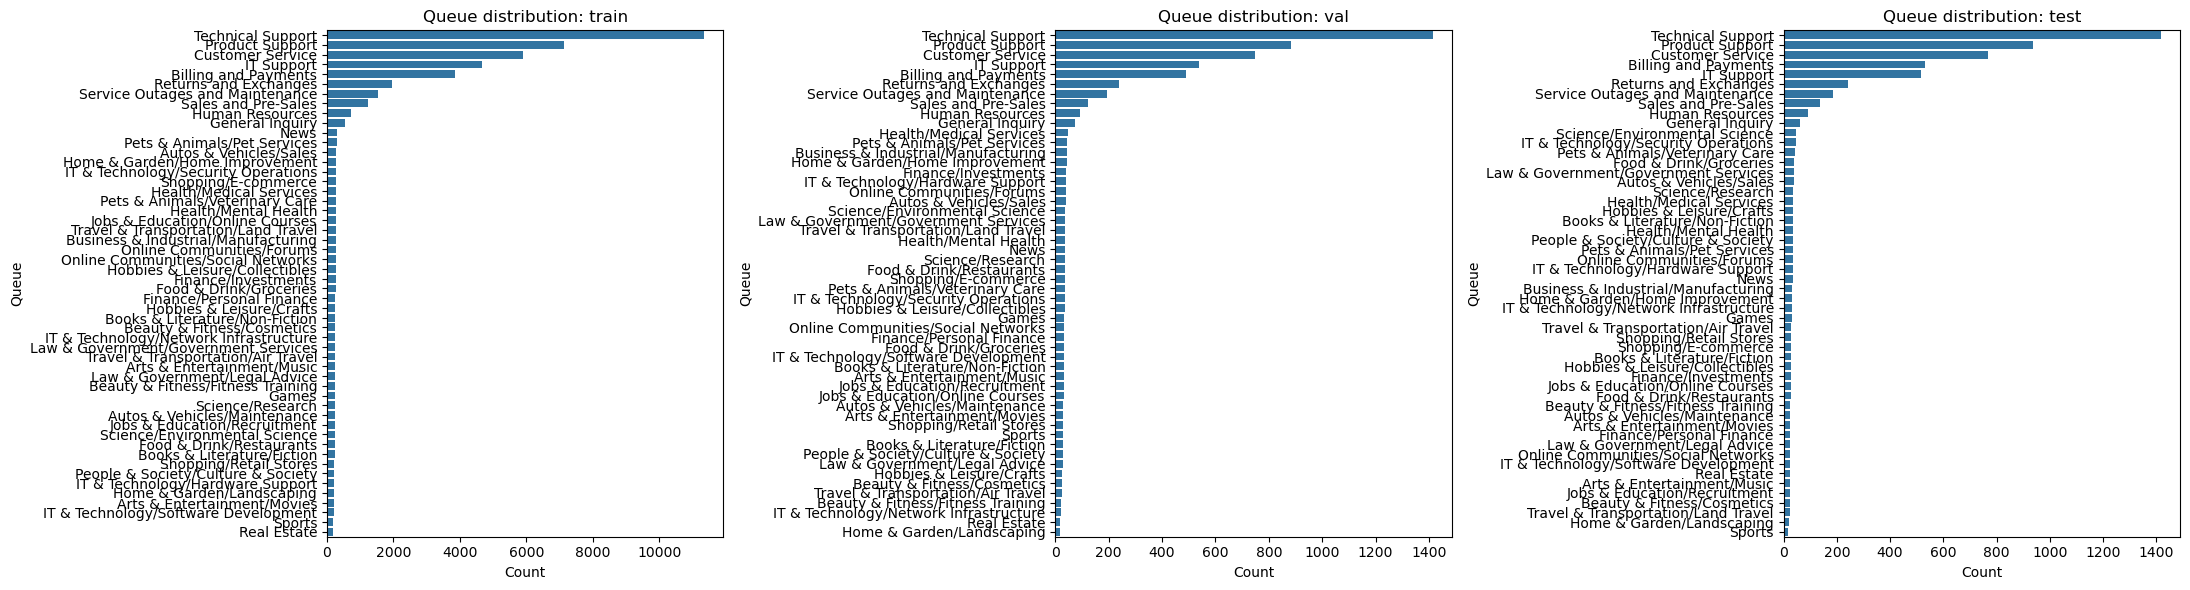

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(data=train_df, y="queue", order=train_df["queue"].value_counts().index, ax=axes[0])
axes[0].set_title("Queue distribution: train")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Queue")

sns.countplot(data=val_df, y="queue", order=val_df["queue"].value_counts().index, ax=axes[1])
axes[1].set_title("Queue distribution: val")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Queue")

sns.countplot(data=test_df, y="queue", order=test_df["queue"].value_counts().index, ax=axes[2])
axes[2].set_title("Queue distribution: test")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Queue")

plt.tight_layout()
plt.show()

По графикам видно, что распределения классов `queue` в `train`, `val` и `test` в целом близки. Крупнейшие классы сохраняют свои позиции во всех трёх выборках, а доли классов не демонстрируют резких скачков между сплитами.

In [14]:
print("TRAIN text length stats (words):")
print(train_df["text_len_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print()

print("VAL text length stats (words):")
print(val_df["text_len_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print()

print("TEST text length stats (words):")
print(test_df["text_len_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print()


TRAIN text length stats (words):
count    49412.000000
mean        62.445438
std         31.205693
min          1.000000
25%         37.000000
50%         62.000000
75%         87.000000
90%         99.000000
95%        108.000000
max        283.000000
Name: text_len_words, dtype: float64

VAL text length stats (words):
count    6176.000000
mean       62.664670
std        31.014043
min         3.000000
25%        37.000000
50%        62.000000
75%        87.000000
90%        98.000000
95%       108.000000
max       235.000000
Name: text_len_words, dtype: float64

TEST text length stats (words):
count    6177.000000
mean       62.062490
std        31.644156
min         2.000000
25%        36.000000
50%        62.000000
75%        86.000000
90%        98.000000
95%       108.000000
max       221.000000
Name: text_len_words, dtype: float64



Анализ длины текстов показывает, что обращения имеют умеренный размер, а распределения длин в `train`, `val` и `test` практически совпадают. Средние значения, медианы и квартили близки между всеми сплитами, что говорит об однородности данных по этому признаку.

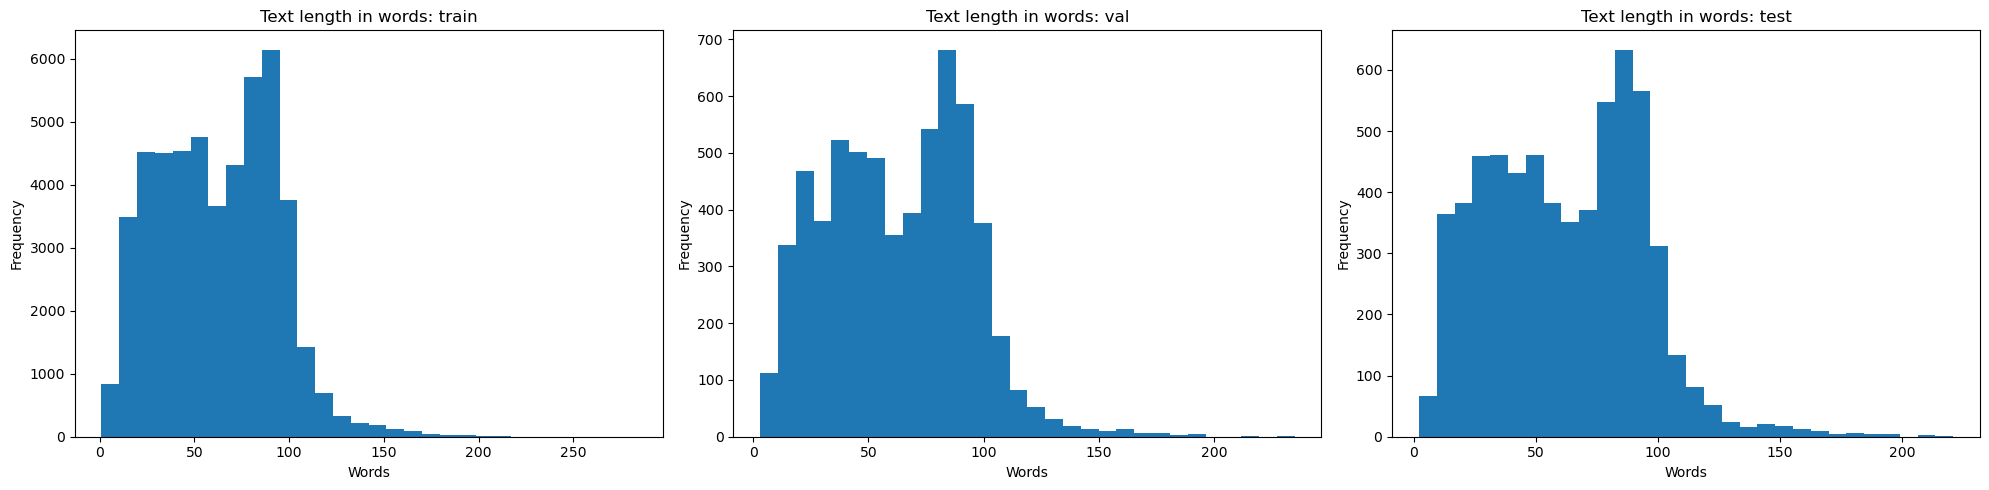

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(train_df["text_len_words"], bins=30)
axes[0].set_title("Text length in words: train")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Frequency")

axes[1].hist(val_df["text_len_words"], bins=30)
axes[1].set_title("Text length in words: val")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

axes[2].hist(test_df["text_len_words"], bins=30)
axes[2].set_title("Text length in words: test")
axes[2].set_xlabel("Words")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


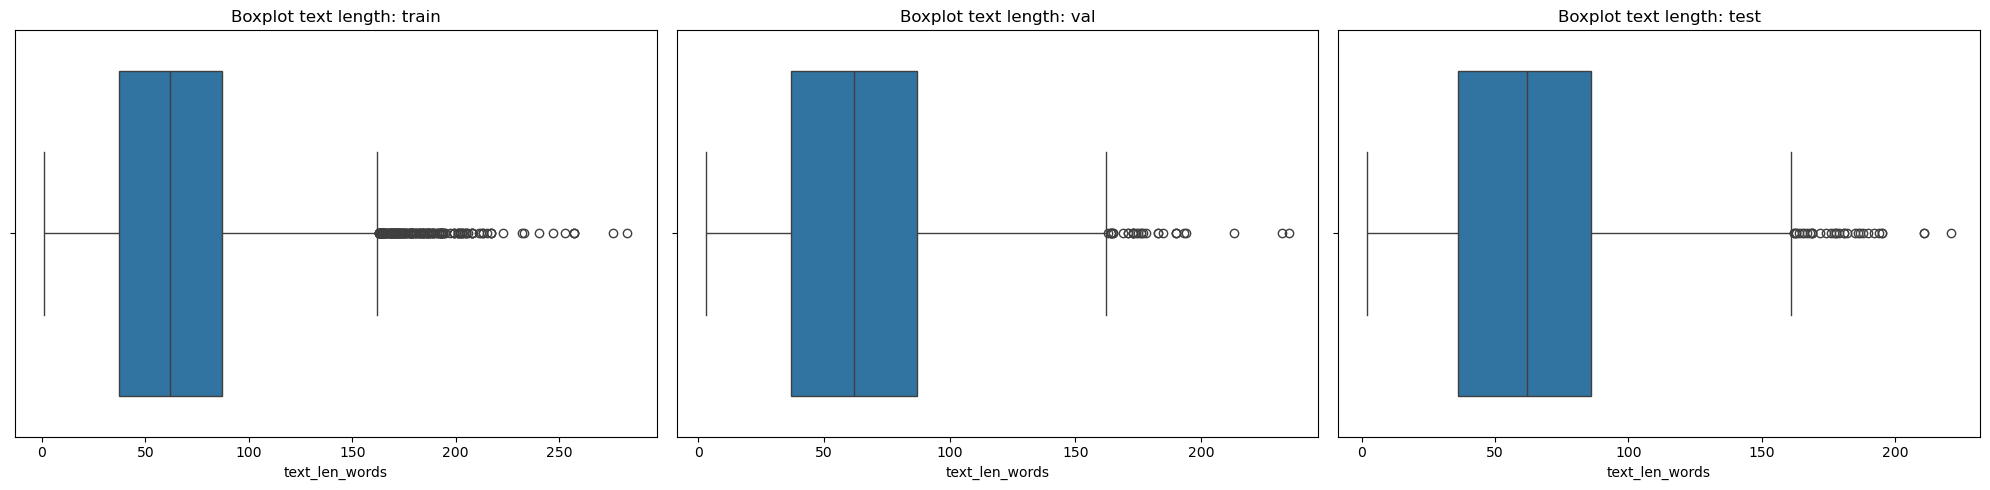

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(x=train_df["text_len_words"], ax=axes[0])
axes[0].set_title("Boxplot text length: train")

sns.boxplot(x=val_df["text_len_words"], ax=axes[1])
axes[1].set_title("Boxplot text length: val")

sns.boxplot(x=test_df["text_len_words"], ax=axes[2])
axes[2].set_title("Boxplot text length: test")

plt.tight_layout()
plt.show()


Boxplot показывает, что в данных присутствуют отдельные длинные обращения, однако их доля невелика. Основная масса объектов сосредоточена в относительно компактном диапазоне, а структура распределения по сплитам остаётся сопоставимой.

In [19]:
print("TRAIN duplicates:", train_df.duplicated().sum())
print("TRAIN duplicates by subject+body:", train_df.duplicated(subset=["subject", "body"]).sum())
print()

print("VAL duplicates:", val_df.duplicated().sum())
print("VAL duplicates by subject+body:", val_df.duplicated(subset=["subject", "body"]).sum())
print()

print("TEST duplicates:", test_df.duplicated().sum())
print("TEST duplicates by subject+body:", test_df.duplicated(subset=["subject", "body"]).sum())

TRAIN duplicates: 6663
TRAIN duplicates by subject+body: 6663

VAL duplicates: 814
VAL duplicates by subject+body: 814

TEST duplicates: 829
TEST duplicates by subject+body: 829


В данных обнаружено заметное количество точных дубликатов по строкам, причём их число совпадает с количеством дубликатов по текстовым полям `subject + body`. Это означает, что повторяются именно текстовые обращения.

In [21]:
def make_text_key(df):
    return (
        df["subject"].fillna("").astype(str).str.strip() + " ||| " +
        df["body"].fillna("").astype(str).str.strip()
    )

train_df["text_key"] = make_text_key(train_df)
val_df["text_key"] = make_text_key(val_df)
test_df["text_key"] = make_text_key(test_df)

train_keys = set(train_df["text_key"])
val_keys = set(val_df["text_key"])
test_keys = set(test_df["text_key"])

train_val_overlap = train_keys & val_keys
train_test_overlap = train_keys & test_keys
val_test_overlap = val_keys & test_keys

print("Пересечения между сплитами:")
print(f"train ∩ val:  {len(train_val_overlap)}")
print(f"train ∩ test: {len(train_test_overlap)}")

Пересечения между сплитами:
train ∩ val:  0
train ∩ test: 0


In [22]:
def find_label_conflicts(df, split_name):
    grouped = df.groupby("text_key").agg(
        n_rows=("text_key", "size"),
        n_queue=("queue", "nunique"),
        n_priority=("priority", "nunique"),
        n_type=("type", "nunique")
    ).reset_index()
    
    conflicts = grouped[
        (grouped["n_rows"] > 1) &
        (
            (grouped["n_queue"] > 1) |
            (grouped["n_priority"] > 1) |
            (grouped["n_type"] > 1)
        )
    ].copy()
    
    print(f"\n===== {split_name} =====")
    print(f"Всего уникальных text_key: {grouped.shape[0]}")
    print(f"Текстов, встречающихся более 1 раза: {(grouped['n_rows'] > 1).sum()}")
    print(f"Текстов с конфликтующими метками: {conflicts.shape[0]}")
    
    return conflicts

train_conflicts = find_label_conflicts(train_df, "TRAIN")
val_conflicts = find_label_conflicts(val_df, "VAL")
test_conflicts = find_label_conflicts(test_df, "TEST")


===== TRAIN =====
Всего уникальных text_key: 42749
Текстов, встречающихся более 1 раза: 6663
Текстов с конфликтующими метками: 0

===== VAL =====
Всего уникальных text_key: 5362
Текстов, встречающихся более 1 раза: 814
Текстов с конфликтующими метками: 0

===== TEST =====
Всего уникальных text_key: 5348
Текстов, встречающихся более 1 раза: 829
Текстов с конфликтующими метками: 0


Дополнительная проверка показала, что одинаковые тексты не пересекаются между `train`, `val` и `test`, то есть явной утечки данных между сплитами не обнаружено. 

При этом внутри каждого сплита присутствует заметное число повторяющихся текстов. Однако для всех таких дублей метки `queue`, `priority` и `type` полностью совпадают, то есть конфликтов разметки не выявлено. Следовательно, обнаруженные дубликаты выглядят как согласованные повторные наблюдения, а не как ошибка разметки или источник противоречивых сигналов для модели.

# Пункт 2

In [25]:
def evaluate_score(
    y_queue_true, y_queue_pred,
    y_priority_true, y_priority_pred,
    y_type_true, y_type_pred
):
    macro_f1_queue = f1_score(y_queue_true, y_queue_pred, average="macro")
    acc_queue = accuracy_score(y_queue_true, y_queue_pred)
    acc_priority = accuracy_score(y_priority_true, y_priority_pred)

    valid_mask = pd.notna(y_type_true)
    if valid_mask.sum() > 0:
        acc_type = accuracy_score(
            y_type_true[valid_mask],
            pd.Series(y_type_pred, index=y_type_true.index)[valid_mask]
        )
    else:
        acc_type = np.nan

    score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        "macro_f1_queue": macro_f1_queue,
        "acc_queue": acc_queue,
        "acc_priority": acc_priority,
        "acc_type": acc_type,
        "score": score
    }


In [26]:
train_df["text_basic"] = train_df["subject"].astype(str).str.strip() + " " + train_df["body"].astype(str).str.strip()
val_df["text_basic"] = val_df["subject"].astype(str).str.strip() + " " + val_df["body"].astype(str).str.strip()
test_df["text_basic"] = test_df["subject"].astype(str).str.strip() + " " + test_df["body"].astype(str).str.strip()

train_df["text_subject_boost"] = (
    train_df["subject"].astype(str).str.strip() + " " +
    train_df["subject"].astype(str).str.strip() + " " +
    train_df["body"].astype(str).str.strip()
)

val_df["text_subject_boost"] = (
    val_df["subject"].astype(str).str.strip() + " " +
    val_df["subject"].astype(str).str.strip() + " " +
    val_df["body"].astype(str).str.strip()
)

test_df["text_subject_boost"] = (
    test_df["subject"].astype(str).str.strip() + " " +
    test_df["subject"].astype(str).str.strip() + " " +
    test_df["body"].astype(str).str.strip()
)

y_train_queue = train_df["queue"]
y_val_queue = val_df["queue"]
y_test_queue = test_df["queue"]

y_train_priority = train_df["priority"]
y_val_priority = val_df["priority"]
y_test_priority = test_df["priority"]

y_train_type = train_df["type"]
y_val_type = val_df["type"]
y_test_type = test_df["type"]


In [28]:
baseline_queue_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        sublinear_tf=True,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=2.0,
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

baseline_priority_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        sublinear_tf=True,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=2.0,
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

baseline_type_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        sublinear_tf=True,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        C=2.0,
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

baseline_queue_pipe.fit(train_df["text_basic"], y_train_queue)
baseline_priority_pipe.fit(train_df["text_basic"], y_train_priority)

type_train_mask = y_train_type.notna()
baseline_type_pipe.fit(
    train_df.loc[type_train_mask, "text_basic"],
    y_train_type[type_train_mask]
)

val_pred_queue = baseline_queue_pipe.predict(val_df["text_basic"])
val_pred_priority = baseline_priority_pipe.predict(val_df["text_basic"])
val_pred_type = baseline_type_pipe.predict(val_df["text_basic"])

baseline_metrics = evaluate_score(
    y_val_queue, val_pred_queue,
    y_val_priority, val_pred_priority,
    y_val_type, val_pred_type
)

print("Simple baseline on VAL")
print(f"Macro-F1(queue): {baseline_metrics['macro_f1_queue']:.4f}")
print(f"Accuracy(queue): {baseline_metrics['acc_queue']:.4f}")
print(f"Accuracy(priority): {baseline_metrics['acc_priority']:.4f}")
print(f"Accuracy(type): {baseline_metrics['acc_type']:.4f}")
print(f"Score: {baseline_metrics['score']:.4f}")


Simple baseline on VAL
Macro-F1(queue): 0.8232
Accuracy(queue): 0.5518
Accuracy(priority): 0.6452
Accuracy(type): 0.8351
Score: 0.7983


### Сравнение линейных baseline-моделей

После построения базового решения были дополнительно исследованы несколько улучшений: сравнение разных линейных классификаторов, увеличение веса поля `subject`, а также использование символьных TF-IDF-признаков наряду со словарными.

In [30]:
baseline_results = []
trained_models = {}

configs = [
    {
        "model_name": "logreg_basic",
        "text_col": "text_basic",
        "vectorizer": TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=70000,
            ngram_range=(1, 2),
            min_df=2
        ),
        "model": LogisticRegression(
            C=2.0,
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )
    },
    {
        "model_name": "logreg_subject_boost",
        "text_col": "text_subject_boost",
        "vectorizer": TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=70000,
            ngram_range=(1, 2),
            min_df=2
        ),
        "model": LogisticRegression(
            C=2.0,
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )
    },
    {
        "model_name": "linearsvc_basic",
        "text_col": "text_basic",
        "vectorizer": TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=70000,
            ngram_range=(1, 2),
            min_df=2
        ),
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        )
    },
    {
        "model_name": "linearsvc_subject_boost",
        "text_col": "text_subject_boost",
        "vectorizer": TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=70000,
            ngram_range=(1, 2),
            min_df=2
        ),
        "model": LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        )
    },
    {
        "model_name": "sgd_logloss_basic",
        "text_col": "text_basic",
        "vectorizer": TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=70000,
            ngram_range=(1, 2),
            min_df=2
        ),
        "model": SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )
    }
]

for cfg in configs:
    text_col = cfg["text_col"]

    queue_pipe = Pipeline([
        ("tfidf", clone(cfg["vectorizer"])),
        ("clf", clone(cfg["model"]))
    ])
    priority_pipe = Pipeline([
        ("tfidf", clone(cfg["vectorizer"])),
        ("clf", clone(cfg["model"]))
    ])
    type_pipe = Pipeline([
        ("tfidf", clone(cfg["vectorizer"])),
        ("clf", clone(cfg["model"]))
    ])

    queue_pipe.fit(train_df[text_col], y_train_queue)
    priority_pipe.fit(train_df[text_col], y_train_priority)

    type_train_mask = y_train_type.notna()
    type_pipe.fit(
        train_df.loc[type_train_mask, text_col],
        y_train_type[type_train_mask]
    )

    val_pred_queue = queue_pipe.predict(val_df[text_col])
    val_pred_priority = priority_pipe.predict(val_df[text_col])
    val_pred_type = type_pipe.predict(val_df[text_col])

    metrics = evaluate_score(
        y_val_queue, val_pred_queue,
        y_val_priority, val_pred_priority,
        y_val_type, val_pred_type
    )

    baseline_results.append({
        "model_name": cfg["model_name"],
        "text_col": text_col,
        "val_macro_f1_queue": metrics["macro_f1_queue"],
        "val_acc_queue": metrics["acc_queue"],
        "val_acc_priority": metrics["acc_priority"],
        "val_acc_type": metrics["acc_type"],
        "val_score": metrics["score"]
    })

    trained_models[cfg["model_name"]] = {
        "queue_model": queue_pipe,
        "priority_model": priority_pipe,
        "type_model": type_pipe,
        "text_col": text_col
    }

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values(
    by=["val_score", "val_macro_f1_queue", "val_acc_queue"],
    ascending=False
).reset_index(drop=True)

baseline_results_df


,model_name,text_col,val_macro_f1_queue,val_acc_queue,val_acc_priority,val_acc_type,val_score
0,linearsvc_basic,text_basic,0.869827,0.627753,0.686205,0.853003,0.839760
1,linearsvc_subject_boost,text_subject_boost,0.865075,0.621114,0.686690,0.855505,0.836882
2,logreg_subject_boost,text_subject_boost,0.834946,0.557157,0.653174,0.841326,0.808637
3,sgd_logloss_basic,text_basic,0.834020,0.556023,0.651878,0.844454,0.808264
4,logreg_basic,text_basic,0.831368,0.556995,0.653659,0.841326,0.806206


In [31]:
word_char_queue_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            analyzer="word"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=30000,
            ngram_range=(3, 5),
            min_df=2,
            analyzer="char_wb"
        ))
    ])),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

word_char_priority_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            analyzer="word"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=30000,
            ngram_range=(3, 5),
            min_df=2,
            analyzer="char_wb"
        ))
    ])),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

word_char_type_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            analyzer="word"
        )),
        ("char_tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_features=30000,
            ngram_range=(3, 5),
            min_df=2,
            analyzer="char_wb"
        ))
    ])),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

word_char_queue_pipe.fit(train_df["text_subject_boost"], y_train_queue)
word_char_priority_pipe.fit(train_df["text_subject_boost"], y_train_priority)

type_train_mask = y_train_type.notna()
word_char_type_pipe.fit(
    train_df.loc[type_train_mask, "text_subject_boost"],
    y_train_type[type_train_mask]
)

val_pred_queue = word_char_queue_pipe.predict(val_df["text_subject_boost"])
val_pred_priority = word_char_priority_pipe.predict(val_df["text_subject_boost"])
val_pred_type = word_char_type_pipe.predict(val_df["text_subject_boost"])

word_char_metrics = evaluate_score(
    y_val_queue, val_pred_queue,
    y_val_priority, val_pred_priority,
    y_val_type, val_pred_type
)

print("Word + Char TF-IDF + LinearSVC on VAL")
print(f"Macro-F1(queue): {word_char_metrics['macro_f1_queue']:.4f}")
print(f"Accuracy(queue): {word_char_metrics['acc_queue']:.4f}")
print(f"Accuracy(priority): {word_char_metrics['acc_priority']:.4f}")
print(f"Accuracy(type): {word_char_metrics['acc_type']:.4f}")
print(f"Score: {word_char_metrics['score']:.4f}")


Word + Char TF-IDF + LinearSVC on VAL
Macro-F1(queue): 0.8858
Accuracy(queue): 0.6308
Accuracy(priority): 0.6867
Accuracy(type): 0.8511
Score: 0.8507


In [32]:
extra_row = pd.DataFrame([{
    "model_name": "word_char_linearsvc_subject_boost",
    "text_col": "text_subject_boost",
    "val_macro_f1_queue": word_char_metrics["macro_f1_queue"],
    "val_acc_queue": word_char_metrics["acc_queue"],
    "val_acc_priority": word_char_metrics["acc_priority"],
    "val_acc_type": word_char_metrics["acc_type"],
    "val_score": word_char_metrics["score"]
}])

all_baseline_results_df = pd.concat([baseline_results_df, extra_row], ignore_index=True)
all_baseline_results_df = all_baseline_results_df.sort_values(
    by=["val_score", "val_macro_f1_queue", "val_acc_queue"],
    ascending=False
).reset_index(drop=True)

all_baseline_results_df


,model_name,text_col,val_macro_f1_queue,val_acc_queue,val_acc_priority,val_acc_type,val_score
0,word_char_linearsvc_subject_boost,text_subject_boost,0.885783,0.630829,0.686690,0.851126,0.850721
1,linearsvc_basic,text_basic,0.869827,0.627753,0.686205,0.853003,0.839760
2,linearsvc_subject_boost,text_subject_boost,0.865075,0.621114,0.686690,0.855505,0.836882
3,logreg_subject_boost,text_subject_boost,0.834946,0.557157,0.653174,0.841326,0.808637
4,sgd_logloss_basic,text_basic,0.834020,0.556023,0.651878,0.844454,0.808264
5,logreg_basic,text_basic,0.831368,0.556995,0.653659,0.841326,0.806206


In [33]:
best_model_name = all_baseline_results_df.iloc[0]["model_name"]
print("Best baseline model on VAL:", best_model_name)

train_val_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

if best_model_name == "word_char_linearsvc_subject_boost":
    final_queue_model = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                analyzer="word"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=30000,
                ngram_range=(3, 5),
                min_df=2,
                analyzer="char_wb"
            ))
        ])),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        ))
    ])

    final_priority_model = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                analyzer="word"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=30000,
                ngram_range=(3, 5),
                min_df=2,
                analyzer="char_wb"
            ))
        ])),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        ))
    ])

    final_type_model = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                analyzer="word"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_features=30000,
                ngram_range=(3, 5),
                min_df=2,
                analyzer="char_wb"
            ))
        ])),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        ))
    ])

    final_train_text = train_val_df["text_subject_boost"]
    final_test_text = test_df["text_subject_boost"]

else:
    chosen_cfg = None
    for cfg in configs:
        if cfg["model_name"] == best_model_name:
            chosen_cfg = cfg
            break

    final_queue_model = Pipeline([
        ("tfidf", clone(chosen_cfg["vectorizer"])),
        ("clf", clone(chosen_cfg["model"]))
    ])
    final_priority_model = Pipeline([
        ("tfidf", clone(chosen_cfg["vectorizer"])),
        ("clf", clone(chosen_cfg["model"]))
    ])
    final_type_model = Pipeline([
        ("tfidf", clone(chosen_cfg["vectorizer"])),
        ("clf", clone(chosen_cfg["model"]))
    ])

    final_train_text = train_val_df[chosen_cfg["text_col"]]
    final_test_text = test_df[chosen_cfg["text_col"]]

final_queue_model.fit(final_train_text, train_val_df["queue"])
final_priority_model.fit(final_train_text, train_val_df["priority"])

type_train_val_mask = train_val_df["type"].notna()
final_type_model.fit(
    final_train_text[type_train_val_mask],
    train_val_df.loc[type_train_val_mask, "type"]
)

test_pred_queue = final_queue_model.predict(final_test_text)
test_pred_priority = final_priority_model.predict(final_test_text)
test_pred_type = final_type_model.predict(final_test_text)

test_metrics = evaluate_score(
    y_test_queue, test_pred_queue,
    y_test_priority, test_pred_priority,
    y_test_type, test_pred_type
)

print("Final baseline results on TEST")
print(f"Macro-F1(queue): {test_metrics['macro_f1_queue']:.4f}")
print(f"Accuracy(queue): {test_metrics['acc_queue']:.4f}")
print(f"Accuracy(priority): {test_metrics['acc_priority']:.4f}")
print(f"Accuracy(type): {test_metrics['acc_type']:.4f}")
print(f"Score: {test_metrics['score']:.4f}")


Best baseline model on VAL: word_char_linearsvc_subject_boost
Final baseline results on TEST
Macro-F1(queue): 0.8917
Accuracy(queue): 0.6463
Accuracy(priority): 0.6837
Accuracy(type): 0.8664
Score: 0.8567


In [35]:
test_pred_queue = final_queue_model.predict(final_test_text)
test_pred_priority = final_priority_model.predict(final_test_text)
test_pred_type = final_type_model.predict(final_test_text)

test_macro_f1 = f1_score(y_test_queue, test_pred_queue, average="macro")
test_acc_queue = accuracy_score(y_test_queue, test_pred_queue)
test_acc_priority = accuracy_score(y_test_priority, test_pred_priority)

valid_mask = pd.notna(y_test_type)
test_acc_type = accuracy_score(
    y_test_type[valid_mask],
    pd.Series(test_pred_type, index=y_test_type.index)[valid_mask]
)

test_score = 0.70 * test_macro_f1 + 0.15 * test_acc_priority + 0.15 * test_acc_type

print("Final baseline results on TEST")
print(f"Macro-F1(queue): {test_macro_f1:.4f}")
print(f"Accuracy(queue): {test_acc_queue:.4f}")
print(f"Accuracy(priority): {test_acc_priority:.4f}")
print(f"Accuracy(type): {test_acc_type:.4f}")
print(f"Score: {test_score:.4f}")

Final baseline results on TEST
Macro-F1(queue): 0.8917
Accuracy(queue): 0.6463
Accuracy(priority): 0.6837
Accuracy(type): 0.8664
Score: 0.8567


## Вывод по пункту 2

В пункте 2 были исследованы несколько baseline-подходов на основе `TF-IDF` и линейных моделей для многозадачной классификации обращений по трём целям: `queue`, `priority` и `type`.

Среди baseline-подходов наилучший результат дала модель `word_char_linearsvc_subject_boost`, и именно её следует рассматривать как основную baseline-модель для дальнейшего анализа.


# Пункт 3

In [39]:
queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

train_df["queue_id"] = queue_le.fit_transform(train_df["queue"])
val_df["queue_id"] = queue_le.transform(val_df["queue"])
test_df["queue_id"] = queue_le.transform(test_df["queue"])

train_df["priority_id"] = priority_le.fit_transform(train_df["priority"])
val_df["priority_id"] = priority_le.transform(val_df["priority"])
test_df["priority_id"] = priority_le.transform(test_df["priority"])

type_le.fit(train_df.loc[train_df["type"].notna(), "type"])

def encode_type_column(series, label_encoder):
    out = []
    for x in series:
        if pd.isna(x):
            out.append(-100)
        else:
            out.append(label_encoder.transform([x])[0])
    return out

train_df["type_id"] = encode_type_column(train_df["type"], type_le)
val_df["type_id"] = encode_type_column(val_df["type"], type_le)
test_df["type_id"] = encode_type_column(test_df["type"], type_le)

num_queue_labels = len(queue_le.classes_)
num_priority_labels = len(priority_le.classes_)
num_type_labels = len(type_le.classes_)

print(num_queue_labels, num_priority_labels, num_type_labels)

52 5 4


In [40]:
class TicketMultiTaskDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=96):
        self.texts = df["text_basic"].tolist()
        self.queue_labels = df["queue_id"].tolist()
        self.priority_labels = df["priority_id"].tolist()
        self.type_labels = df["type_id"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.queue_labels[idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(self.priority_labels[idx], dtype=torch.long)
        item["labels_type"] = torch.tensor(self.type_labels[idx], dtype=torch.long)
        return item

In [43]:
class MultiTaskTransformer(nn.Module):
    def __init__(
        self,
        model_name,
        num_queue_labels,
        num_priority_labels,
        num_type_labels,
        dropout=0.2,
        freeze_embeddings=True,
        freeze_first_n_layers=3
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.queue_head = nn.Linear(hidden_size, num_queue_labels)
        self.priority_head = nn.Linear(hidden_size, num_priority_labels)
        self.type_head = nn.Linear(hidden_size, num_type_labels)

        self.loss_queue_fn = nn.CrossEntropyLoss()
        self.loss_priority_fn = nn.CrossEntropyLoss()
        self.loss_type_fn = nn.CrossEntropyLoss(ignore_index=-100)

        if freeze_embeddings:
            if hasattr(self.encoder, "embeddings"):
                for p in self.encoder.embeddings.parameters():
                    p.requires_grad = False

        if hasattr(self.encoder, "transformer") and hasattr(self.encoder.transformer, "layer"):
            for layer in self.encoder.transformer.layer[:freeze_first_n_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels_queue=None,
        labels_priority=None,
        labels_type=None
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        logits_queue = self.queue_head(pooled)
        logits_priority = self.priority_head(pooled)
        logits_type = self.type_head(pooled)

        loss = None
        if labels_queue is not None:
            loss_queue = self.loss_queue_fn(logits_queue, labels_queue)
            loss_priority = self.loss_priority_fn(logits_priority, labels_priority)
            loss_type = self.loss_type_fn(logits_type, labels_type)

            loss = 0.7 * loss_queue + 0.15 * loss_priority + 0.15 * loss_type

        return {
            "loss": loss,
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type
        }

In [45]:
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_queue = inputs.pop("labels_queue")
        labels_priority = inputs.pop("labels_priority")
        labels_type = inputs.pop("labels_type")

        outputs = model(
            **inputs,
            labels_queue=labels_queue,
            labels_priority=labels_priority,
            labels_type=labels_type
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels_queue = inputs.pop("labels_queue")
        labels_priority = inputs.pop("labels_priority")
        labels_type = inputs.pop("labels_type")

        with torch.no_grad():
            outputs = model(
                **inputs,
                labels_queue=labels_queue,
                labels_priority=labels_priority,
                labels_type=labels_type
            )

        loss = outputs["loss"].detach()

        logits = (
            outputs["logits_queue"].detach(),
            outputs["logits_priority"].detach(),
            outputs["logits_type"].detach()
        )

        labels = (
            labels_queue.detach(),
            labels_priority.detach(),
            labels_type.detach()
        )

        return (loss, logits, labels)

In [47]:
def compute_multitask_metrics(eval_preds):
    logits, labels = eval_preds

    logits_queue, logits_priority, logits_type = logits
    labels_queue, labels_priority, labels_type = labels

    pred_queue = np.argmax(logits_queue, axis=1)
    pred_priority = np.argmax(logits_priority, axis=1)
    pred_type = np.argmax(logits_type, axis=1)

    macro_f1_queue = f1_score(labels_queue, pred_queue, average="macro")
    acc_queue = accuracy_score(labels_queue, pred_queue)
    acc_priority = accuracy_score(labels_priority, pred_priority)

    valid_mask = labels_type != -100
    if valid_mask.sum() > 0:
        acc_type = accuracy_score(labels_type[valid_mask], pred_type[valid_mask])
    else:
        acc_type = np.nan

    score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * (0 if np.isnan(acc_type) else acc_type)

    return {
        "macro_f1_queue": macro_f1_queue,
        "acc_queue": acc_queue,
        "acc_priority": acc_priority,
        "acc_type": acc_type,
        "score": score
    }

In [49]:
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = TicketMultiTaskDataset(train_df, tokenizer, max_length=MAX_LENGTH)
val_dataset = TicketMultiTaskDataset(val_df, tokenizer, max_length=MAX_LENGTH)
test_dataset = TicketMultiTaskDataset(test_df, tokenizer, max_length=MAX_LENGTH)

In [51]:
model = MultiTaskTransformer(
    model_name=MODEL_NAME,
    num_queue_labels=num_queue_labels,
    num_priority_labels=num_priority_labels,
    num_type_labels=num_type_labels,
    dropout=0.2,
    freeze_embeddings=True,
    freeze_first_n_layers=3
)

training_args = TrainingArguments(
    output_dir="./fast_multitask_distilmbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16 if torch.cuda.is_available() else 8,
    per_device_eval_batch_size=32 if torch.cuda.is_available() else 16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="score",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_multitask_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1 Queue,Acc Queue,Acc Priority,Acc Type,Score
1,1.644200,nan,0.651846,0.483161,0.485913,0.780651,0.646277
2,1.265900,nan,0.717298,0.509715,0.502105,0.787740,0.695585


TrainOutput(global_step=6178, training_loss=1.4550607767102015, metrics={'train_runtime': 266.4487, 'train_samples_per_second': 370.893, 'train_steps_per_second': 23.186, 'total_flos': 0.0, 'train_loss': 1.4550607767102015, 'epoch': 2.0})

In [52]:
val_metrics = trainer.evaluate(val_dataset)
val_metrics

{'eval_loss': nan,
 'eval_macro_f1_queue': 0.7172977169808635,
 'eval_acc_queue': 0.5097150259067358,
 'eval_acc_priority': 0.5021049222797928,
 'eval_acc_type': 0.7877397831526272,
 'eval_score': 0.6955851077014674,
 'eval_runtime': 6.5054,
 'eval_samples_per_second': 949.37,
 'eval_steps_per_second': 29.668,
 'epoch': 2.0}

In [53]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_dataset = TicketMultiTaskDataset(train_val_df, tokenizer, max_length=MAX_LENGTH)

final_model = MultiTaskTransformer(
    model_name=MODEL_NAME,
    num_queue_labels=num_queue_labels,
    num_priority_labels=num_priority_labels,
    num_type_labels=num_type_labels,
    dropout=0.2,
    freeze_embeddings=True,
    freeze_first_n_layers=3
)

final_training_args = TrainingArguments(
    output_dir="./fast_multitask_distilmbert_final",
    eval_strategy="no",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16 if torch.cuda.is_available() else 8,
    per_device_eval_batch_size=32 if torch.cuda.is_available() else 16,
    num_train_epochs=4,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False
)

final_trainer = MultiTaskTrainer(
    model=final_model,
    args=final_training_args,
    train_dataset=train_val_dataset,
    compute_metrics=compute_multitask_metrics
)

final_trainer.train()


Step,Training Loss
3475,1.578000
6950,1.200300
10425,1.091000
13900,1.024600


TrainOutput(global_step=13900, training_loss=1.2234766503203687, metrics={'train_runtime': 559.6412, 'train_samples_per_second': 397.312, 'train_steps_per_second': 24.837, 'total_flos': 0.0, 'train_loss': 1.2234766503203687, 'epoch': 4.0})

In [65]:
test_output = final_trainer.predict(test_dataset)

test_metrics = compute_multitask_metrics(
    (test_output.predictions, test_output.label_ids)
)

print("Final multitask transformer results on TEST")
print(f"Macro-F1(queue): {test_metrics['macro_f1_queue']:.4f}")
print(f"Accuracy(queue): {test_metrics['acc_queue']:.4f}")
print(f"Accuracy(priority): {test_metrics['acc_priority']:.4f}")
print(f"Accuracy(type): {test_metrics['acc_type']:.4f}")
print(f"Score: {test_metrics['score']:.4f}")

Final multitask transformer results on TEST
Macro-F1(queue): 0.8138
Accuracy(queue): 0.5577
Accuracy(priority): 0.5435
Accuracy(type): 0.8070
Score: 0.7722


## Вывод по пункту 3

В пункте 3 была обучена multitask transformer-модель на основе `distilbert-base-multilingual-cased`, которая одновременно предсказывает три целевые переменные: `queue`, `priority` и `type`.

Несмотря на то, что transformer-модель показала приемлемый результат, она существенно уступает лучшей линейной baseline-модели из пункта 2. Разница особенно заметна по основной составляющей итогового score — `Macro-F1(queue)`, а также по итоговому `Score`.

Это означает, что в данной задаче более сложная нейросетевая архитектура не дала выигрыша по сравнению с хорошо настроенной линейной моделью на `TF-IDF` признаках. 

## Выбор модели для confidence-анализа

Для confidence-анализа была выбрана не transformer-модель из пункта 3, а лучшая baseline-модель из пункта 2 — `word_char_linearsvc_subject_boost`.

Такой выбор обоснован тем, что именно эта модель показала наилучший результат по метрике:
- `Score на test = 0.8567`

In [75]:
test_pred_queue = final_queue_model.predict(final_test_text)
test_pred_priority = final_priority_model.predict(final_test_text)
test_pred_type = final_type_model.predict(final_test_text)

queue_scores = final_queue_model.decision_function(final_test_text)
priority_scores = final_priority_model.decision_function(final_test_text)
type_scores = final_type_model.decision_function(final_test_text)

queue_conf = np.max(queue_scores, axis=1)
priority_conf = np.max(priority_scores, axis=1)
type_conf = np.max(type_scores, axis=1)

In [76]:
def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    if x.max() == x.min():
        return np.ones_like(x)
    return (x - x.min()) / (x.max() - x.min())

queue_conf_scaled = minmax_scale(queue_conf)
priority_conf_scaled = minmax_scale(priority_conf)
type_conf_scaled = minmax_scale(type_conf)

joint_confidence = (
    0.70 * queue_conf_scaled +
    0.15 * priority_conf_scaled +
    0.15 * type_conf_scaled
)

In [77]:
def confidence_evaluation_curve(
    y_queue_true,
    y_queue_pred,
    y_priority_true,
    y_priority_pred,
    y_type_true,
    y_type_pred,
    confidence,
    coverages=np.arange(0.0, 1.01, 0.05)
):
    y_queue_true = np.array(y_queue_true)
    y_queue_pred = np.array(y_queue_pred)

    y_priority_true = np.array(y_priority_true)
    y_priority_pred = np.array(y_priority_pred)

    y_type_true = np.array(y_type_true, dtype=object)
    y_type_pred = np.array(y_type_pred, dtype=object)

    confidence = np.array(confidence)

    order = np.argsort(-confidence)
    n = len(y_queue_true)

    rows = []

    for coverage in coverages:
        k = int(np.floor(n * coverage))
        k = max(k, 1)

        idx = order[:k]

        queue_true_k = y_queue_true[idx]
        queue_pred_k = y_queue_pred[idx]

        priority_true_k = y_priority_true[idx]
        priority_pred_k = y_priority_pred[idx]

        type_true_k = y_type_true[idx]
        type_pred_k = y_type_pred[idx]

        macro_f1_queue = f1_score(queue_true_k, queue_pred_k, average="macro")
        acc_queue = accuracy_score(queue_true_k, queue_pred_k)
        acc_priority = accuracy_score(priority_true_k, priority_pred_k)

        valid_mask = pd.notna(type_true_k)
        if valid_mask.sum() > 0:
            acc_type = accuracy_score(type_true_k[valid_mask], type_pred_k[valid_mask])
        else:
            acc_type = np.nan

        score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

        rows.append({
            "coverage": coverage,
            "auto_share": coverage,
            "manual_share": 1 - coverage,
            "n_auto": k,
            "n_manual": n - k,
            "macro_f1_queue": macro_f1_queue,
            "accuracy_queue": acc_queue,
            "accuracy_priority": acc_priority,
            "accuracy_type": acc_type,
            "score": score,
            "confidence_threshold": confidence[idx][-1]
        })

    return pd.DataFrame(rows)

In [78]:
confidence_baseline_df = confidence_evaluation_curve(
    y_queue_true=y_test_queue,
    y_queue_pred=test_pred_queue,
    y_priority_true=y_test_priority,
    y_priority_pred=test_pred_priority,
    y_type_true=y_test_type,
    y_type_pred=test_pred_type,
    confidence=joint_confidence,
    coverages=np.arange(0.0, 1.01, 0.05)
)

confidence_baseline_df

,coverage,auto_share,manual_share,n_auto,n_manual,macro_f1_queue,accuracy_queue,accuracy_priority,accuracy_type,score,confidence_threshold
0,0.00,0.00,1.00,1,6176,1.000000,1.000000,1.000000,1.000000,1.000000,0.829460
1,0.05,0.05,0.95,308,5869,1.000000,1.000000,0.811688,0.879747,0.953715,0.444247
2,0.10,0.10,0.90,617,5560,1.000000,1.000000,0.831442,0.861472,0.953937,0.393888
3,0.15,0.15,0.85,926,5251,1.000000,1.000000,0.858531,0.858586,0.957568,0.360088
4,0.20,0.20,0.80,1235,4942,0.977539,0.997571,0.868826,0.853994,0.942700,0.327115
5,0.25,0.25,0.75,1544,4633,0.971129,0.994171,0.878886,0.860000,0.940623,0.286915
6,0.30,0.30,0.70,1853,4324,0.974911,0.978953,0.875337,0.892235,0.947573,0.243785
7,0.35,0.35,0.65,2161,4016,0.966071,0.952800,0.866266,0.911210,0.942871,0.213929
8,0.40,0.40,0.60,2470,3707,0.957091,0.921457,0.850202,0.920767,0.935609,0.195141
9,0.45,0.45,0.55,2779,3398,0.945785,0.884851,0.823678,0.931909,0.925388,0.182450


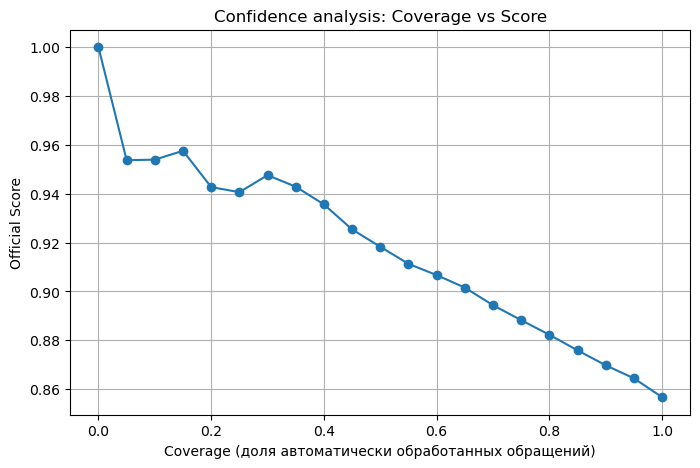

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(confidence_baseline_df["coverage"], confidence_baseline_df["score"], marker="o")
plt.xlabel("Coverage (доля автоматически обработанных обращений)")
plt.ylabel("Official Score")
plt.title("Confidence analysis: Coverage vs Score")
plt.grid(True)
plt.show()

На всей тестовой выборке (`coverage = 1.00`) модель показывает:

- `Macro-F1(queue) = 0.8917`
- `Score = 0.8567`

При дальнейшем уменьшении `coverage` значение `Score` постепенно растёт. По графику видно, что:

- при `coverage` около `0.80` `Score` уже выше, чем на полной выборке;
- в диапазоне `0.50–0.70` качество продолжает улучшаться;
- на малых значениях `coverage` (`0.10–0.30`) достигаются максимальные значения `Score` — примерно `0.95–0.96`.

При этом на самых малых coverage наблюдаются небольшие колебания метрики.

Итоговая интерпретация такая: модель можно использовать не только в полностью автоматическом режиме, но и в полуавтоматическом сценарии. В таком случае наиболее уверенные обращения можно обрабатывать автоматически, а менее уверенные передавать на ручную проверку. Это позволяет повысить качество автоматических решений по метрике, если допустимо уменьшить долю полностью автоматической обработки.